
=== Gemma vs Human ===

Random Forest Accuracy for Gemma: 0.80
              precision    recall  f1-score   support

           0       0.83      0.77      0.79       247
           1       0.78      0.84      0.81       250

    accuracy                           0.80       497
   macro avg       0.80      0.80      0.80       497
weighted avg       0.80      0.80      0.80       497

Confusion Matrix:
 [[189  58]
 [ 40 210]]

Logistic Regression Accuracy for Gemma: 0.75
              precision    recall  f1-score   support

           0       0.74      0.75      0.75       247
           1       0.75      0.74      0.75       250

    accuracy                           0.75       497
   macro avg       0.75      0.75      0.75       497
weighted avg       0.75      0.75      0.75       497

Confusion Matrix:
 [[186  61]
 [ 65 185]]

SVM Accuracy for Gemma: 0.75
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       247
           1 

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest Accuracy for Mistral: 0.84
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       247
           1       0.82      0.86      0.84       250

    accuracy                           0.84       497
   macro avg       0.84      0.84      0.84       497
weighted avg       0.84      0.84      0.84       497

Confusion Matrix:
 [[201  46]
 [ 35 215]]

Logistic Regression Accuracy for Mistral: 0.79
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       247
           1       0.81      0.78      0.79       250

    accuracy                           0.79       497
   macro avg       0.80      0.79      0.79       497
weighted avg       0.80      0.79      0.79       497

Confusion Matrix:
 [[200  47]
 [ 55 195]]

SVM Accuracy for Mistral: 0.80
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       247
           1       0.81      0.

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest Accuracy for LLaMa 3.3 70B: 0.90
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       247
           1       0.89      0.91      0.90       250

    accuracy                           0.90       497
   macro avg       0.90      0.90      0.90       497
weighted avg       0.90      0.90      0.90       497

Confusion Matrix:
 [[218  29]
 [ 23 227]]

Logistic Regression Accuracy for LLaMa 3.3 70B: 0.84
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       247
           1       0.87      0.80      0.84       250

    accuracy                           0.84       497
   macro avg       0.85      0.84      0.84       497
weighted avg       0.85      0.84      0.84       497

Confusion Matrix:
 [[218  29]
 [ 49 201]]

SVM Accuracy for LLaMa 3.3 70B: 0.84
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       247
           1 

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Random Forest Accuracy for GPT 4.1: 0.91
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       247
           1       0.89      0.92      0.91       250

    accuracy                           0.91       497
   macro avg       0.91      0.91      0.91       497
weighted avg       0.91      0.91      0.91       497

Confusion Matrix:
 [[220  27]
 [ 20 230]]

Logistic Regression Accuracy for GPT 4.1: 0.85
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       247
           1       0.85      0.86      0.85       250

    accuracy                           0.85       497
   macro avg       0.85      0.85      0.85       497
weighted avg       0.85      0.85      0.85       497

Confusion Matrix:
 [[209  38]
 [ 35 215]]

SVM Accuracy for GPT 4.1: 0.86
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       247
           1       0.84      0.

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:14:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


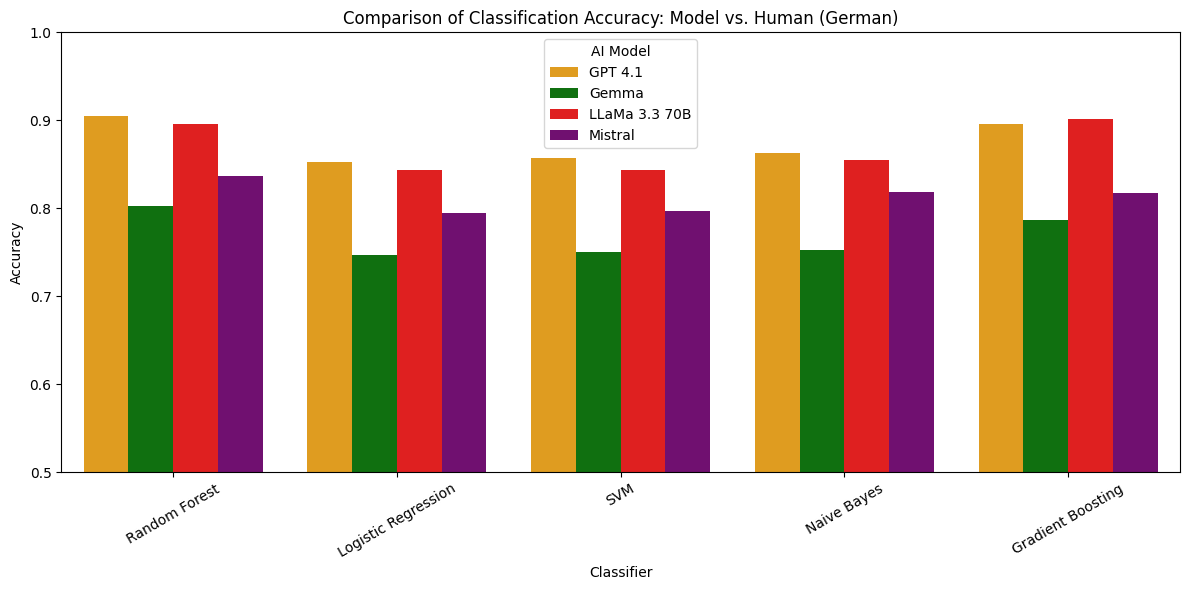

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier

# =====================================================
# STEP 1: Load and prepare AI + Human features
# =====================================================

# Load AI parquet
ai_df = pd.read_parquet("combined_results_En.parquet").reset_index()

if "label" not in ai_df.columns:
    raise ValueError("AI Parquet file must contain 'label' column")

# Extract model name
def extract_model_name(exp_name):
    if "Gemma" in exp_name:
        return "Gemma"
    elif "Mistral" in exp_name:
        return "Mistral"
    elif "Llama" in exp_name:
        return "LLaMa 3.3 70B"
    elif "GPT" in exp_name:
        return "GPT 4.1"
    else:
        return "Other"

ai_df["model"] = ai_df["experiment_name"].apply(extract_model_name)

# Map label ids → human-readable categories
label_map = {
    "LABEL_0": "perceived_space",
    "LABEL_1": "action_space",
    "LABEL_2": "visual_space",
    "LABEL_3": "descriptive_space",
    "LABEL_4": "no_space"
}
ai_df["label"] = ai_df["label"].replace(label_map)

# Human JSON
with open("gutenberg_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

human_rows = []
for item in data:
    human_rows.append({
        "document_id": item["filename"].strip(),
        "label": item["prediction"]["label"]
    })
human_df = pd.DataFrame(human_rows)

# =====================================================
# STEP 2: Classifier Setup
# =====================================================

classifiers = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

ai_models = ["Gemma", "Mistral", "LLaMa 3.3 70B", "GPT 4.1"]
results = []

# =====================================================
# STEP 3: Training loop per model
# =====================================================

for model in ai_models:
    print(f"\n=== {model} vs Human ===")

    # AI subset for this model
    ai_subset = ai_df[ai_df["model"] == model]

    if ai_subset.empty:
        print(f"Skipping {model}, no AI samples found")
        continue

    # AI per-document distribution
    ai_features = ai_subset.pivot_table(
        index="document_id",
        columns="label",
        aggfunc="size",
        fill_value=0
    )
    ai_features = ai_features.div(ai_features.sum(axis=1), axis=0)
    ai_features["target"] = 1

    # Human per-document distribution
    human_features = human_df.pivot_table(
        index="document_id",
        columns="label",
        aggfunc="size",
        fill_value=0
    )
    human_features = human_features.div(human_features.sum(axis=1), axis=0)
    human_features["target"] = 0

    # Combine
    combined = pd.concat([ai_features, human_features], axis=0)

    # Train/test split
    X = combined.drop(columns=["target"])
    y = combined["target"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=42, test_size=0.25
    )

    # Train all classifiers
    for clf_name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        print(f"\n{clf_name} Accuracy for {model}: {acc:.2f}")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

        results.append({
            "Model": model,
            "Classifier": clf_name,
            "Accuracy": acc
        })

# =====================================================
# STEP 4: Visualization (Updated with colors & order)
# =====================================================

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))

# Fixed order of models
model_order = ["GPT 4.1", "Gemma", "LLaMa 3.3 70B", "Mistral"]
model_colors = {
    "GPT 4.1": "orange",
    "Gemma": "green",
    "LLaMa 3.3 70B": "red",
    "Mistral": "purple"
}

sns.barplot(
    data=results_df,
    x="Classifier",
    y="Accuracy",
    hue="Model",
    hue_order=model_order,
    palette=model_colors
)

plt.title("Comparison of Classification Accuracy: Model vs. Human (English)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0.5, 1.0)
plt.legend(title="AI Model")
plt.tight_layout()
plt.show()
